In [1]:
import glob
from pathlib import Path

import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import pyarrow.parquet as pq
import torch
import torch.nn as nn
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

seed = 0
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
import pandas as pd

Using device: cuda


In [2]:
#load 3000 events per process
DATA_ROOT = Path("hack-data/C1_HH4b/train")
N_EVENTS_PER_SAMPLE = 3000   # small subset per process -- bump this up once you trust the pipeline
N_PARTICLES_MAX = 16        # candidates kept per event (truncate/zero-pad), matches the original tutorial
CAND_FIELDS = ["pt", "eta", "phi", "dxy"]

SAMPLES = sorted(p.name for p in DATA_ROOT.iterdir() if p.is_dir())
print("Samples found:", SAMPLES)

Samples found: ['HH_4b', 'QCD_HT250toInf', 'WJetsToLNu_13TeV-madgraphMLM-pythia8', 'WJetsToQQ_13TeV-madgraphMLM-pythia8', 'tt0123j_5f_ckm_LO_MLM_hadronic', 'tt0123j_5f_ckm_LO_MLM_leptonic', 'tt0123j_5f_ckm_LO_MLM_semiLeptonic']


In [3]:
# Read in just the first N events of a sample's first train fragment
def read_first_fragment(sample_dir: Path, n_events: int) -> ak.Array:
    frag = sorted(sample_dir.glob(f"{sample_dir.name}_*.parquet"))[0]
    pf = pq.ParquetFile(frag)
    batch = next(pf.iter_batches(batch_size=n_events, columns=["L1T_PUPPIPart", "label"]))
    return ak.from_arrow(batch)

# Reorganize the data into (N_events, N_particles, N_features) padded tensors (not variable length)
def load_physics_dataset_from_pvc(samples, n_events_per_sample=N_EVENTS_PER_SAMPLE,
                                   n_particles_max=N_PARTICLES_MAX, fields=CAND_FIELDS):
    X_parts, y_parts = [], []

    for sample in samples:
        arr = read_first_fragment(DATA_ROOT / sample, n_events_per_sample)
        cands = arr["L1T_PUPPIPart"]
        labels = ak.to_numpy(arr["label"])

        per_field = []
        for f in fields:
            padded = ak.pad_none(cands[f], n_particles_max, clip=True, axis=1)
            per_field.append(ak.to_numpy(ak.fill_none(padded, 0.0)).astype(np.float32))
        # each entry in per_field is (N_events, N_particles) -> stack into (N_events, N_particles, N_features)
        sample_X = np.stack(per_field, axis=-1)

        X_parts.append(sample_X)
        y_parts.append(labels)
        print(f"{sample}: loaded {len(arr)} events, label={labels[0]}")

    X = np.concatenate(X_parts, axis=0).astype(np.float32)
    y = np.concatenate(y_parts, axis=0).astype(np.int64)
    return X, y


X, y = load_physics_dataset_from_pvc(SAMPLES)
print(X.shape, y.shape)  # (N_total_events, N_particles, N_features), (N_total_events,)
print("Class counts:", {int(c): int((y == c).sum()) for c in np.unique(y)})

HH_4b: loaded 3000 events, label=1
QCD_HT250toInf: loaded 3000 events, label=0
WJetsToLNu_13TeV-madgraphMLM-pythia8: loaded 3000 events, label=3
WJetsToQQ_13TeV-madgraphMLM-pythia8: loaded 3000 events, label=3
tt0123j_5f_ckm_LO_MLM_hadronic: loaded 3000 events, label=2
tt0123j_5f_ckm_LO_MLM_leptonic: loaded 3000 events, label=2
tt0123j_5f_ckm_LO_MLM_semiLeptonic: loaded 3000 events, label=2
(21000, 16, 4) (21000,)
Class counts: {0: 3000, 1: 3000, 2: 9000, 3: 6000}


**This is a jagged array understand the schema**

In [4]:
frames = []
for sample in SAMPLES:
    arr = read_first_fragment(DATA_ROOT / sample, N_EVENTS_PER_SAMPLE)

    df = ak.to_dataframe(arr["L1T_PUPPIPart"])
    df = df.join(ak.to_dataframe(arr[["label"]]), on="entry")
    df["sample"] = sample
    frames.append(df)

df_parts = pd.concat(frames, ignore_index=False)

print(df_parts.shape)
print(df_parts["label"].value_counts())
df_parts

(10373662, 16)
label
2    4463150
3    2936686
1    1489070
0    1484756
Name: count, dtype: int64


/opt/conda/lib/python3.12/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


pt       eta       phi       dxy    dxysig  pdgId  \
entry subentry                                                             
0     0         31.015625 -0.142578  2.445312  0.000000   0.00000      0   
      1         27.859375 -1.784180 -1.127930  0.000113   1.12793     13   
      2         14.164062  2.173828 -1.049805  0.000000   0.00000     22   
      3         14.007812 -0.313232  2.527344  0.000000   0.00000     22   
      4         12.179688 -1.968750 -1.166992 -0.003944 -39.43750    211   
...                   ...       ...       ...       ...       ...    ...   
2999  473        1.285156  1.875000 -1.957031  0.000000   0.00000     22   
      474        1.282227  2.751953 -0.499512  0.000000   0.00000     22   
      475        1.281250  1.617188  0.099792  0.000000   0.00000      0   
      476        1.280273  1.732422  0.160767  0.000000   0.00000      0   
      477        1.280273 -1.021484 -0.019348  0.000000   0.00000     22   

                charge  pt_weighted  puppi_weight          e          mass  \
entry subentry                                                               
0     0              0     9.671875      0.311768  31.343750  3.576279e-07   
      1              1    27.859375      1.000000  85.250000  1.056519e-01   
      2              0     0.000000      0.000000  63.093750  1.370907e-06   
      3              0     5.136719      0.366699  14.695312  0.000000e+00   
      4             -1    12.179688      1.000000  44.500000  1.395264e-01   
...                ...          ...           ...        ...           ...   
2999  473            0     0.000000      0.000000   4.289062  5.960464e-08   
      474            0     0.000000      0.000000  10.093750  1.192093e-07   
      475            0     0.000000      0.000000   3.353516  5.960464e-08   
      476            0     0.000000      0.000000   3.734375  5.960464e-08   
      477            0     0.000000      0.000000   2.009766  0.000000e+00   

                     dz  error_dz  funique_id  label  \
entry subentry                                         
0     0          0.0000       0.0       92489      1   
      1         46.7500       0.0       74821      1   
      2          0.0000       0.0       90768      1   
      3          0.0000       0.0       90254      1   
      4         46.8125       0.0       89169      1   
...                 ...       ...         ...    ...   
2999  473        0.0000       0.0       83794      2   
      474        0.0000       0.0       84126      2   
      475        0.0000       0.0       85608      2   
      476        0.0000       0.0       85635      2   
      477        0.0000       0.0       83369      2   

                                            sample  
entry subentry                                      
0     0                                      HH_4b  
      1                                      HH_4b  
      2                                      HH_4b  
      3                                      HH_4b  
      4                                      HH_4b  
...                                            ...  
2999  473       tt0123j_5f_ckm_LO_MLM_semiLeptonic  
      474       tt0123j_5f_ckm_LO_MLM_semiLeptonic  
      475       tt0123j_5f_ckm_LO_MLM_semiLeptonic  
      476       tt0123j_5f_ckm_LO_MLM_semiLeptonic  
      477       tt0123j_5f_ckm_LO_MLM_semiLeptonic  

[10373662 rows x 16 columns]

**Clean the Data**

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

**Factor in class imbalanace with the labels**

In [6]:
df_final = df_parts.copy()

In [7]:
df_final["label"].value_counts()

label
2    4463150
3    2936686
1    1489070
0    1484756
Name: count, dtype: int64

**drop funique id**

In [8]:
df_final = df_final.drop(columns=["funique_id"])
df_final

/opt/conda/lib/python3.12/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


pt       eta       phi       dxy    dxysig  pdgId  \
entry subentry                                                             
0     0         31.015625 -0.142578  2.445312  0.000000   0.00000      0   
      1         27.859375 -1.784180 -1.127930  0.000113   1.12793     13   
      2         14.164062  2.173828 -1.049805  0.000000   0.00000     22   
      3         14.007812 -0.313232  2.527344  0.000000   0.00000     22   
      4         12.179688 -1.968750 -1.166992 -0.003944 -39.43750    211   
...                   ...       ...       ...       ...       ...    ...   
2999  473        1.285156  1.875000 -1.957031  0.000000   0.00000     22   
      474        1.282227  2.751953 -0.499512  0.000000   0.00000     22   
      475        1.281250  1.617188  0.099792  0.000000   0.00000      0   
      476        1.280273  1.732422  0.160767  0.000000   0.00000      0   
      477        1.280273 -1.021484 -0.019348  0.000000   0.00000     22   

                charge  pt_weighted  puppi_weight          e          mass  \
entry subentry                                                               
0     0              0     9.671875      0.311768  31.343750  3.576279e-07   
      1              1    27.859375      1.000000  85.250000  1.056519e-01   
      2              0     0.000000      0.000000  63.093750  1.370907e-06   
      3              0     5.136719      0.366699  14.695312  0.000000e+00   
      4             -1    12.179688      1.000000  44.500000  1.395264e-01   
...                ...          ...           ...        ...           ...   
2999  473            0     0.000000      0.000000   4.289062  5.960464e-08   
      474            0     0.000000      0.000000  10.093750  1.192093e-07   
      475            0     0.000000      0.000000   3.353516  5.960464e-08   
      476            0     0.000000      0.000000   3.734375  5.960464e-08   
      477            0     0.000000      0.000000   2.009766  0.000000e+00   

                     dz  error_dz  label                              sample  
entry subentry                                                                
0     0          0.0000       0.0      1                               HH_4b  
      1         46.7500       0.0      1                               HH_4b  
      2          0.0000       0.0      1                               HH_4b  
      3          0.0000       0.0      1                               HH_4b  
      4         46.8125       0.0      1                               HH_4b  
...                 ...       ...    ...                                 ...  
2999  473        0.0000       0.0      2  tt0123j_5f_ckm_LO_MLM_semiLeptonic  
      474        0.0000       0.0      2  tt0123j_5f_ckm_LO_MLM_semiLeptonic  
      475        0.0000       0.0      2  tt0123j_5f_ckm_LO_MLM_semiLeptonic  
      476        0.0000       0.0      2  tt0123j_5f_ckm_LO_MLM_semiLeptonic  
      477        0.0000       0.0      2  tt0123j_5f_ckm_LO_MLM_semiLeptonic  

[10373662 rows x 15 columns]

In [9]:
df_final.dtypes

pt              float16
eta             float16
phi             float16
dxy             float16
dxysig          float16
pdgId             int16
charge             int8
pt_weighted     float16
puppi_weight    float16
e               float16
mass            float16
dz              float16
error_dz        float16
label              int8
sample           object
dtype: object

**Data Cleaning**
- each entry is an event, a single collision inside of the interaction point
- each subentry is an object within that event
- each column represents the repspective value for that particle within that event
- look for null, 0 or sential values within columns

**Drop error_dz column**
- sential values, all values are 0.0

In [10]:
columns = ["error_dz", "mass", "e", "pt"]
filtered = df_final[df_final["error_dz"] == 0]

In [11]:
filtered

/opt/conda/lib/python3.12/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


pt       eta       phi       dxy    dxysig  pdgId  \
entry subentry                                                             
0     0         31.015625 -0.142578  2.445312  0.000000   0.00000      0   
      1         27.859375 -1.784180 -1.127930  0.000113   1.12793     13   
      2         14.164062  2.173828 -1.049805  0.000000   0.00000     22   
      3         14.007812 -0.313232  2.527344  0.000000   0.00000     22   
      4         12.179688 -1.968750 -1.166992 -0.003944 -39.43750    211   
...                   ...       ...       ...       ...       ...    ...   
2999  473        1.285156  1.875000 -1.957031  0.000000   0.00000     22   
      474        1.282227  2.751953 -0.499512  0.000000   0.00000     22   
      475        1.281250  1.617188  0.099792  0.000000   0.00000      0   
      476        1.280273  1.732422  0.160767  0.000000   0.00000      0   
      477        1.280273 -1.021484 -0.019348  0.000000   0.00000     22   

                charge  pt_weighted  puppi_weight          e          mass  \
entry subentry                                                               
0     0              0     9.671875      0.311768  31.343750  3.576279e-07   
      1              1    27.859375      1.000000  85.250000  1.056519e-01   
      2              0     0.000000      0.000000  63.093750  1.370907e-06   
      3              0     5.136719      0.366699  14.695312  0.000000e+00   
      4             -1    12.179688      1.000000  44.500000  1.395264e-01   
...                ...          ...           ...        ...           ...   
2999  473            0     0.000000      0.000000   4.289062  5.960464e-08   
      474            0     0.000000      0.000000  10.093750  1.192093e-07   
      475            0     0.000000      0.000000   3.353516  5.960464e-08   
      476            0     0.000000      0.000000   3.734375  5.960464e-08   
      477            0     0.000000      0.000000   2.009766  0.000000e+00   

                     dz  error_dz  label                              sample  
entry subentry                                                                
0     0          0.0000       0.0      1                               HH_4b  
      1         46.7500       0.0      1                               HH_4b  
      2          0.0000       0.0      1                               HH_4b  
      3          0.0000       0.0      1                               HH_4b  
      4         46.8125       0.0      1                               HH_4b  
...                 ...       ...    ...                                 ...  
2999  473        0.0000       0.0      2  tt0123j_5f_ckm_LO_MLM_semiLeptonic  
      474        0.0000       0.0      2  tt0123j_5f_ckm_LO_MLM_semiLeptonic  
      475        0.0000       0.0      2  tt0123j_5f_ckm_LO_MLM_semiLeptonic  
      476        0.0000       0.0      2  tt0123j_5f_ckm_LO_MLM_semiLeptonic  
      477        0.0000       0.0      2  tt0123j_5f_ckm_LO_MLM_semiLeptonic  

[10373662 rows x 15 columns]

In [12]:
df_final = df_final.drop(columns=["error_dz"])
df_final

/opt/conda/lib/python3.12/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


pt       eta       phi       dxy    dxysig  pdgId  \
entry subentry                                                             
0     0         31.015625 -0.142578  2.445312  0.000000   0.00000      0   
      1         27.859375 -1.784180 -1.127930  0.000113   1.12793     13   
      2         14.164062  2.173828 -1.049805  0.000000   0.00000     22   
      3         14.007812 -0.313232  2.527344  0.000000   0.00000     22   
      4         12.179688 -1.968750 -1.166992 -0.003944 -39.43750    211   
...                   ...       ...       ...       ...       ...    ...   
2999  473        1.285156  1.875000 -1.957031  0.000000   0.00000     22   
      474        1.282227  2.751953 -0.499512  0.000000   0.00000     22   
      475        1.281250  1.617188  0.099792  0.000000   0.00000      0   
      476        1.280273  1.732422  0.160767  0.000000   0.00000      0   
      477        1.280273 -1.021484 -0.019348  0.000000   0.00000     22   

                charge  pt_weighted  puppi_weight          e          mass  \
entry subentry                                                               
0     0              0     9.671875      0.311768  31.343750  3.576279e-07   
      1              1    27.859375      1.000000  85.250000  1.056519e-01   
      2              0     0.000000      0.000000  63.093750  1.370907e-06   
      3              0     5.136719      0.366699  14.695312  0.000000e+00   
      4             -1    12.179688      1.000000  44.500000  1.395264e-01   
...                ...          ...           ...        ...           ...   
2999  473            0     0.000000      0.000000   4.289062  5.960464e-08   
      474            0     0.000000      0.000000  10.093750  1.192093e-07   
      475            0     0.000000      0.000000   3.353516  5.960464e-08   
      476            0     0.000000      0.000000   3.734375  5.960464e-08   
      477            0     0.000000      0.000000   2.009766  0.000000e+00   

                     dz  label                              sample  
entry subentry                                                      
0     0          0.0000      1                               HH_4b  
      1         46.7500      1                               HH_4b  
      2          0.0000      1                               HH_4b  
      3          0.0000      1                               HH_4b  
      4         46.8125      1                               HH_4b  
...                 ...    ...                                 ...  
2999  473        0.0000      2  tt0123j_5f_ckm_LO_MLM_semiLeptonic  
      474        0.0000      2  tt0123j_5f_ckm_LO_MLM_semiLeptonic  
      475        0.0000      2  tt0123j_5f_ckm_LO_MLM_semiLeptonic  
      476        0.0000      2  tt0123j_5f_ckm_LO_MLM_semiLeptonic  
      477        0.0000      2  tt0123j_5f_ckm_LO_MLM_semiLeptonic  

[10373662 rows x 14 columns]

In [13]:
df_final[df_final["pdgId"] == 0]

/opt/conda/lib/python3.12/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


pt       eta       phi  dxy  dxysig  pdgId  charge  \
entry subentry                                                              
0     0         31.015625 -0.142578  2.445312  0.0     0.0      0       0   
      6         10.320312  0.895020  0.268066  0.0     0.0      0       0   
      7          9.953125 -0.310791  0.354736  0.0     0.0      0       0   
      8          8.625000 -2.365234 -0.280029  0.0     0.0      0       0   
      9          8.507812 -1.779297 -1.126953  0.0     0.0      0       0   
...                   ...       ...       ...  ...     ...    ...     ...   
2999  470        1.291992 -2.121094  3.123047  0.0     0.0      0       0   
      471        1.290039  1.150391  1.401367  0.0     0.0      0       0   
      472        1.289062 -1.083008 -0.427002  0.0     0.0      0       0   
      475        1.281250  1.617188  0.099792  0.0     0.0      0       0   
      476        1.280273  1.732422  0.160767  0.0     0.0      0       0   

                pt_weighted  puppi_weight          e          mass   dz  \
entry subentry                                                            
0     0            9.671875      0.311768  31.343750  3.576279e-07  0.0   
      6            0.000000      0.000000  14.742188 -1.788139e-07  0.0   
      7            0.000000      0.000000  10.437500 -1.192093e-07  0.0   
      8            0.000000      0.000000  46.343750  0.000000e+00  0.0   
      9            0.000000      0.000000  25.921875  0.000000e+00  0.0   
...                     ...           ...        ...           ...  ...   
2999  470          0.000000      0.000000   5.457031  1.788139e-07  0.0   
      471          0.000000      0.000000   2.242188  0.000000e+00  0.0   
      472          0.000000      0.000000   2.123047  5.960464e-08  0.0   
      475          0.000000      0.000000   3.353516  5.960464e-08  0.0   
      476          0.000000      0.000000   3.734375  5.960464e-08  0.0   

                label                              sample  
entry subentry                                             
0     0             1                               HH_4b  
      6             1                               HH_4b  
      7             1                               HH_4b  
      8             1                               HH_4b  
      9             1                               HH_4b  
...               ...                                 ...  
2999  470           2  tt0123j_5f_ckm_LO_MLM_semiLeptonic  
      471           2  tt0123j_5f_ckm_LO_MLM_semiLeptonic  
      472           2  tt0123j_5f_ckm_LO_MLM_semiLeptonic  
      475           2  tt0123j_5f_ckm_LO_MLM_semiLeptonic  
      476           2  tt0123j_5f_ckm_LO_MLM_semiLeptonic  

[7338221 rows x 14 columns]

In [14]:
df_final["Has_Dummy_Particle"] = np.where(df_final["pdgId"] == 0, True, False).astype(bool)

In [15]:
df_final

/opt/conda/lib/python3.12/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


pt       eta       phi       dxy    dxysig  pdgId  \
entry subentry                                                             
0     0         31.015625 -0.142578  2.445312  0.000000   0.00000      0   
      1         27.859375 -1.784180 -1.127930  0.000113   1.12793     13   
      2         14.164062  2.173828 -1.049805  0.000000   0.00000     22   
      3         14.007812 -0.313232  2.527344  0.000000   0.00000     22   
      4         12.179688 -1.968750 -1.166992 -0.003944 -39.43750    211   
...                   ...       ...       ...       ...       ...    ...   
2999  473        1.285156  1.875000 -1.957031  0.000000   0.00000     22   
      474        1.282227  2.751953 -0.499512  0.000000   0.00000     22   
      475        1.281250  1.617188  0.099792  0.000000   0.00000      0   
      476        1.280273  1.732422  0.160767  0.000000   0.00000      0   
      477        1.280273 -1.021484 -0.019348  0.000000   0.00000     22   

                charge  pt_weighted  puppi_weight          e          mass  \
entry subentry                                                               
0     0              0     9.671875      0.311768  31.343750  3.576279e-07   
      1              1    27.859375      1.000000  85.250000  1.056519e-01   
      2              0     0.000000      0.000000  63.093750  1.370907e-06   
      3              0     5.136719      0.366699  14.695312  0.000000e+00   
      4             -1    12.179688      1.000000  44.500000  1.395264e-01   
...                ...          ...           ...        ...           ...   
2999  473            0     0.000000      0.000000   4.289062  5.960464e-08   
      474            0     0.000000      0.000000  10.093750  1.192093e-07   
      475            0     0.000000      0.000000   3.353516  5.960464e-08   
      476            0     0.000000      0.000000   3.734375  5.960464e-08   
      477            0     0.000000      0.000000   2.009766  0.000000e+00   

                     dz  label                              sample  \
entry subentry                                                       
0     0          0.0000      1                               HH_4b   
      1         46.7500      1                               HH_4b   
      2          0.0000      1                               HH_4b   
      3          0.0000      1                               HH_4b   
      4         46.8125      1                               HH_4b   
...                 ...    ...                                 ...   
2999  473        0.0000      2  tt0123j_5f_ckm_LO_MLM_semiLeptonic   
      474        0.0000      2  tt0123j_5f_ckm_LO_MLM_semiLeptonic   
      475        0.0000      2  tt0123j_5f_ckm_LO_MLM_semiLeptonic   
      476        0.0000      2  tt0123j_5f_ckm_LO_MLM_semiLeptonic   
      477        0.0000      2  tt0123j_5f_ckm_LO_MLM_semiLeptonic   

                Has_Dummy_Particle  
entry subentry                      
0     0                       True  
      1                      False  
      2                      False  
      3                      False  
      4                      False  
...                            ...  
2999  473                    False  
      474                    False  
      475                     True  
      476                     True  
      477                    False  

[10373662 rows x 15 columns]

In [16]:
def subatomic_particles(charge):
    if charge == 0:
        return "Netural"
    elif charge == 1:
        return "Positive"
    else:
        return "Negative"

In [17]:
df_final["Subatomic_Charge_classification"] = df_final["charge"].apply(subatomic_particles)

In [18]:
df_final["Subatomic_Charge_classification"] = df_final["Subatomic_Charge_classification"].replace(
    "Netural", "Neutral"
)

In [19]:
for col in ["pt", "eta", "phi", "dxy", "dxysig", "pdgId", "charge",
            "pt_weighted", "puppi_weight", "e", "mass", "dz"]:
    n_zero = (df_parts[col] == 0).sum()
    pct = 100 * n_zero / len(df_parts)
    print(f"{col:15s}: {n_zero:>8} zeros ({pct:.2f}%)")

pt             :        0 zeros (0.00%)
eta            :        0 zeros (0.00%)
phi            :        0 zeros (0.00%)
dxy            : 10219037 zeros (98.51%)
dxysig         : 10213582 zeros (98.46%)
pdgId          :  7338221 zeros (70.74%)
charge         :  9047607 zeros (87.22%)
pt_weighted    :  9731903 zeros (93.81%)
puppi_weight   :  9731903 zeros (93.81%)
e              :        0 zeros (0.00%)
mass           :  2630301 zeros (25.36%)
dz             :  9047607 zeros (87.22%)


**Check for Nulls**

In [20]:
print(df_parts.isna().sum())

pt              0
eta             0
phi             0
dxy             0
dxysig          0
pdgId           0
charge          0
pt_weighted     0
puppi_weight    0
e               0
mass            0
dz              0
error_dz        0
funique_id      0
label           0
sample          0
dtype: int64


**Drop rows in dxysifg where it goes to positive or negative infinity**

In [21]:
cols = ["pt", "eta", "phi", "dxy", "dxysig", "pdgId", "charge",
        "pt_weighted", "puppi_weight", "e", "mass", "dz"]

print(df_final[cols].describe().T)

/opt/conda/lib/python3.12/site-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
/opt/conda/lib/python3.12/site-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/opt/conda/lib/python3.12/site-packages/pandas/core/nanops.py:731: RuntimeWarning: invalid value encountered in scalar divide
  the_mean = the_sum / count if count > 0 else np.nan
/opt/conda/lib/python3.12/site-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
/opt/conda/lib/python3.12/site-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
/opt/conda/lib/python3.12/site-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
/opt/conda/lib/python3.12/site-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow enco

                   count       mean        std         min       25%  \
pt            10373662.0        NaN   0.000000    1.000000  1.824219   
eta           10373662.0  -0.000000   0.000000   -3.000000 -1.494141   
phi           10373662.0   0.000000   0.000000   -3.140625 -1.571289   
dxy           10373662.0  -0.000000   0.000000  -51.187500  0.000000   
dxysig        10373662.0        NaN        NaN        -inf  0.000000   
pdgId         10373662.0  30.138138  68.993705    0.000000  0.000000   
charge        10373662.0   0.000454   0.357532   -1.000000  0.000000   
pt_weighted   10373662.0        NaN   0.000000    0.000000  0.000000   
puppi_weight  10373662.0        NaN   0.000000    0.000000  0.000000   
e             10373662.0        NaN   0.000000    1.021484  3.349609   
mass          10373662.0        NaN   0.000000   -0.000031  0.000000   
dz            10373662.0        NaN   0.000000 -232.125000  0.000000   

                       50%           75%          max  
pt     

In [22]:
float_cols = df_final.select_dtypes(include=[np.floating]).columns

inf_summary = {}
for col in float_cols:
    n_pos = np.isinf(df_final[col]).sum() and (df_final[col] == np.inf).sum()
    n_neg = (df_final[col] == -np.inf).sum()
    if n_pos + n_neg > 0:
        inf_summary[col] = {"+inf": int(n_pos), "-inf": int(n_neg)}

print(inf_summary)

{'dxysig': {'+inf': 1592, '-inf': 1620}}


In [23]:
inf_mask = np.isinf(df_final["dxysig"])
inf_rows = df_final[inf_mask]

print(f"{len(inf_rows)} rows ({100*len(inf_rows)/len(df_final):.3f}% of dataset)")
inf_rows[["pt", "eta", "dxy", "dxysig", "puppi_weight", "sample", "label"]].head(20)

3212 rows (0.031% of dataset)


/opt/conda/lib/python3.12/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


pt       eta        dxy  dxysig  puppi_weight sample  \
entry subentry                                                               
4     7         9.718750  1.408203   6.761719     inf           1.0  HH_4b   
6     8         7.910156  1.182617   8.445312     inf           1.0  HH_4b   
9     157       3.345703  1.483398  12.640625     inf           1.0  HH_4b   
11    206       2.769531 -1.025391  -9.109375    -inf           1.0  HH_4b   
      324       2.277344  0.452637   7.949219     inf           1.0  HH_4b   
18    80        5.472656 -0.591309   9.054688     inf           1.0  HH_4b   
28    159       3.544922 -0.764648 -16.796875    -inf           1.0  HH_4b   
34    199       2.441406 -0.643066  13.507812     inf           1.0  HH_4b   
41    264       2.761719 -0.567383   7.828125     inf           1.0  HH_4b   
45    175       2.980469 -0.905273 -11.390625    -inf           1.0  HH_4b   
      245       2.501953 -0.898926  13.765625     inf           1.0  HH_4b   
48    113       4.292969  0.028290  13.976562     inf           1.0  HH_4b   
49    235       2.080078 -2.095703  -8.710938    -inf           1.0  HH_4b   
52    160       2.621094  0.572754 -16.531250    -inf           1.0  HH_4b   
57    152       2.556641  0.128418 -16.781250    -inf           1.0  HH_4b   
60    221       2.568359 -0.501465   8.078125     inf           1.0  HH_4b   
61    211       2.183594 -0.476318  32.250000     inf           1.0  HH_4b   
65    205       2.710938 -1.518555 -12.703125    -inf           1.0  HH_4b   
66    145       2.746094 -0.259033   9.742188     inf           1.0  HH_4b   
67    165       2.617188 -0.020035 -12.710938    -inf           1.0  HH_4b   

                label  
entry subentry         
4     7             1  
6     8             1  
9     157           1  
11    206           1  
      324           1  
18    80            1  
28    159           1  
34    199           1  
41    264           1  
45    175           1  
      245           1  
48    113           1  
49    235           1  
52    160           1  
57    152           1  
60    221           1  
61    211           1  
65    205           1  
66    145           1  
67    165           1

In [24]:
inf_mask = np.isinf(df_final["dxysig"])

df_final = df_final[~inf_mask]

print(f"Dropped {inf_mask.sum()} rows")
print(f"Remaining: {len(df_final)} rows")

Dropped 3212 rows
Remaining: 10370450 rows


In [25]:
df_final

/opt/conda/lib/python3.12/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


pt       eta       phi       dxy    dxysig  pdgId  \
entry subentry                                                             
0     0         31.015625 -0.142578  2.445312  0.000000   0.00000      0   
      1         27.859375 -1.784180 -1.127930  0.000113   1.12793     13   
      2         14.164062  2.173828 -1.049805  0.000000   0.00000     22   
      3         14.007812 -0.313232  2.527344  0.000000   0.00000     22   
      4         12.179688 -1.968750 -1.166992 -0.003944 -39.43750    211   
...                   ...       ...       ...       ...       ...    ...   
2999  473        1.285156  1.875000 -1.957031  0.000000   0.00000     22   
      474        1.282227  2.751953 -0.499512  0.000000   0.00000     22   
      475        1.281250  1.617188  0.099792  0.000000   0.00000      0   
      476        1.280273  1.732422  0.160767  0.000000   0.00000      0   
      477        1.280273 -1.021484 -0.019348  0.000000   0.00000     22   

                charge  pt_weighted  puppi_weight          e          mass  \
entry subentry                                                               
0     0              0     9.671875      0.311768  31.343750  3.576279e-07   
      1              1    27.859375      1.000000  85.250000  1.056519e-01   
      2              0     0.000000      0.000000  63.093750  1.370907e-06   
      3              0     5.136719      0.366699  14.695312  0.000000e+00   
      4             -1    12.179688      1.000000  44.500000  1.395264e-01   
...                ...          ...           ...        ...           ...   
2999  473            0     0.000000      0.000000   4.289062  5.960464e-08   
      474            0     0.000000      0.000000  10.093750  1.192093e-07   
      475            0     0.000000      0.000000   3.353516  5.960464e-08   
      476            0     0.000000      0.000000   3.734375  5.960464e-08   
      477            0     0.000000      0.000000   2.009766  0.000000e+00   

                     dz  label                              sample  \
entry subentry                                                       
0     0          0.0000      1                               HH_4b   
      1         46.7500      1                               HH_4b   
      2          0.0000      1                               HH_4b   
      3          0.0000      1                               HH_4b   
      4         46.8125      1                               HH_4b   
...                 ...    ...                                 ...   
2999  473        0.0000      2  tt0123j_5f_ckm_LO_MLM_semiLeptonic   
      474        0.0000      2  tt0123j_5f_ckm_LO_MLM_semiLeptonic   
      475        0.0000      2  tt0123j_5f_ckm_LO_MLM_semiLeptonic   
      476        0.0000      2  tt0123j_5f_ckm_LO_MLM_semiLeptonic   
      477        0.0000      2  tt0123j_5f_ckm_LO_MLM_semiLeptonic   

                Has_Dummy_Particle Subatomic_Charge_classification  
entry subentry                                                      
0     0                       True                         Neutral  
      1                      False                        Positive  
      2                      False                         Neutral  
      3                      False                         Neutral  
      4                      False                        Negative  
...                            ...                             ...  
2999  473                    False                         Neutral  
      474                    False                         Neutral  
      475                     True                         Neutral  
      476                     True                         Neutral  
      477                    False                         Neutral  

[10370450 rows x 16 columns]

**Check for Duplicates**

In [26]:
n_dupes = df_final.duplicated().sum()
print(f"{n_dupes} exact duplicate rows")

10 exact duplicate rows


In [27]:
df_final = df_final.drop_duplicates()
print(f"Dropped {n_dupes} duplicate rows, {len(df_final)} rows remaining")

Dropped 10 duplicate rows, 10370440 rows remaining


**Exploratory Data Analysis**

In [28]:
pivot = df_final.pivot_table(index="Subatomic_Charge_classification", values="pt", aggfunc="count")
pivot = pivot.rename(columns={"pt": "Count"})
pivot = pivot.sort_values(by="Count", ascending=False)
pivot

,Count
Subatomic_Charge_classification,
Neutral,9047597
Positive,663793
Negative,659050


In [29]:
pivot1 = df_final.pivot_table(index="Has_Dummy_Particle", values="pt", aggfunc="count")
pivot1 = pivot1.rename(columns={"pt": "Count"})
pivot1 = pivot1.sort_values(by="Count", ascending=False)
pivot1

,Count
Has_Dummy_Particle,
True,7338212
False,3032228


In [30]:
pivot2 = df_final.pivot_table(index="Subatomic_Charge_classification", columns="label", values="charge", aggfunc="count")
pivot2

label,0,1,2,3
Subatomic_Charge_classification,,,,
Negative,97492,104767,311388,145403
Neutral,1290479,1278130,3834115,2644873
Positive,96297,105558,315857,146081


In [31]:
pivot3 = df_final.pivot_table(index="Has_Dummy_Particle", columns="label", values="charge", aggfunc="count")
pivot3

label,0,1,2,3
Has_Dummy_Particle,,,,
False,440763,460890,1370970,759605
True,1043505,1027565,3090390,2176752


In [32]:
pivot4 = df_final.pivot_table(index="sample", values="charge", aggfunc="count")
pivot4 = pivot4.rename(columns={"charge": "Count"})
pivot4 = pivot4.sort_values(by="Count", ascending=False)
pivot4

,Count
sample,
tt0123j_5f_ckm_LO_MLM_semiLeptonic,1490277
tt0123j_5f_ckm_LO_MLM_hadronic,1489795
HH_4b,1488455
QCD_HT250toInf,1484268
tt0123j_5f_ckm_LO_MLM_leptonic,1481288
WJetsToQQ_13TeV-madgraphMLM-pythia8,1468909
WJetsToLNu_13TeV-madgraphMLM-pythia8,1467448


In [33]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", None)

important_cols = ["pt", "eta", "e", "mass", "dxy", "dz"]
df_final.groupby("label")[important_cols].agg(["mean", "std", "median", "min", "max"])

/opt/conda/lib/python3.12/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


pt                                            eta            \
           mean       std    median       min    max      mean       std   
label                                                                      
0      3.111212  4.392517  2.275391  1.128906  544.0 -0.004358  1.720256   
1      3.245233  4.738294  2.339844  1.131836  876.5 -0.007645  1.703592   
2      3.357706  5.847063  2.330078  1.023438  935.5 -0.003426  1.707083   
3      2.600293  2.223977  2.138672  1.000000  512.0  0.001505  1.760968   

                                  e                                         \
         median  min  max      mean        std    median       min     max   
label                                                                        
0     -0.007011 -3.0  3.0  9.607728  15.528236  6.246094  1.157227  1900.0   
1     -0.011986 -3.0  3.0  9.659664  14.261241  6.355469  1.173828  2866.0   
2     -0.007612 -3.0  3.0  9.900115  15.819921  6.367188  1.052734  3034.0   
3     -0.000739 -3.0  3.0  8.620702   9.990956  5.968750  1.021484  1280.0   

           mass                                                   dxy  \
           mean       std        median       min       max      mean   
label                                                                   
0      0.043170  0.159157  5.960464e-08 -0.000015  1.672852 -0.000068   
1      0.046139  0.162937  5.960464e-08 -0.000031  1.321289  0.000036   
2      0.045354  0.161099  5.960464e-08 -0.000022  1.672852 -0.000014   
3      0.035117  0.148373  5.960464e-08 -0.000015  1.672852 -0.000063   

                                                  dz                    \
            std median       min       max      mean        std median   
label                                                                    
0      0.099739    0.0 -6.546875  6.531250  0.031716  19.112531    0.0   
1      0.130975    0.0 -6.542969  6.550781 -0.072480  19.938687    0.0   
2      0.117157    0.0 -6.539062  6.535156  0.004012  19.924601    0.0   
3      0.054195   -0.0 -6.527344  6.546875 -0.019761  16.734216    0.0   

                         
           min      max  
label                    
0     -207.250  232.875  
1     -227.625  231.750  
2     -224.500  223.875  
3     -232.125  222.000

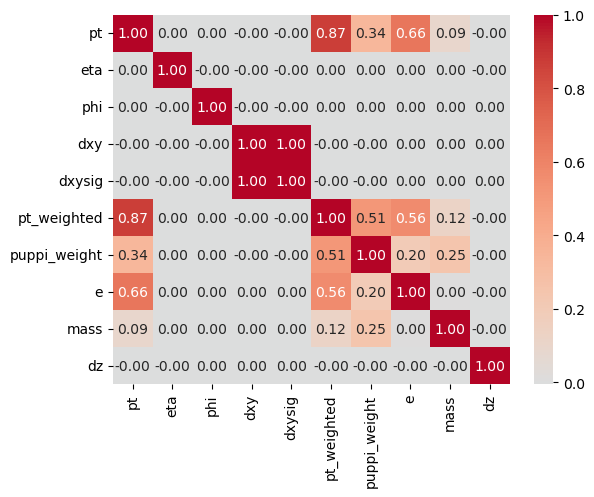

In [34]:
cols = ["pt", "eta", "phi", "dxy", "dxysig", "pt_weighted", "puppi_weight", "e", "mass", "dz"]
corr = df_final[cols].astype(np.float64).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.show()

In [35]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

Y = (df_final["label"] == 1).astype(int)   # 1 = signal (HH_4b), 0 = everything else

classes = np.array([0, 1])
weights = compute_class_weight("balanced", classes=classes, y=Y)
class_weight_dict = dict(zip(classes, weights))
print(class_weight_dict)

{np.int64(0): np.float64(0.5837906729182722), np.int64(1): np.float64(3.4836256386655964)}


**Build Classification Models**

In [36]:
df_final.head(5)

/opt/conda/lib/python3.12/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


pt       eta       phi       dxy    dxysig  pdgId  \
entry subentry                                                             
0     0         31.015625 -0.142578  2.445312  0.000000   0.00000      0   
      1         27.859375 -1.784180 -1.127930  0.000113   1.12793     13   
      2         14.164062  2.173828 -1.049805  0.000000   0.00000     22   
      3         14.007812 -0.313232  2.527344  0.000000   0.00000     22   
      4         12.179688 -1.968750 -1.166992 -0.003944 -39.43750    211   

                charge  pt_weighted  puppi_weight          e          mass  \
entry subentry                                                               
0     0              0     9.671875      0.311768  31.343750  3.576279e-07   
      1              1    27.859375      1.000000  85.250000  1.056519e-01   
      2              0     0.000000      0.000000  63.093750  1.370907e-06   
      3              0     5.136719      0.366699  14.695312  0.000000e+00   
      4             -1    12.179688      1.000000  44.500000  1.395264e-01   

                     dz  label sample  Has_Dummy_Particle  \
entry subentry                                              
0     0          0.0000      1  HH_4b                True   
      1         46.7500      1  HH_4b               False   
      2          0.0000      1  HH_4b               False   
      3          0.0000      1  HH_4b               False   
      4         46.8125      1  HH_4b               False   

               Subatomic_Charge_classification  
entry subentry                                  
0     0                                Neutral  
      1                               Positive  
      2                                Neutral  
      3                                Neutral  
      4                               Negative

In [37]:
Y = (df_final["label"] == 1).astype(int)   # 1 = signal (label==1), 0 = everything else

n_total = len(Y)
n_class1 = (Y == 1).sum()
n_class0 = (Y == 0).sum()

weight_1 = n_total / (2 * n_class1)
weight_0 = n_total / (2 * n_class0)

class_weight_dict = {0: weight_0, 1: weight_1}
print(class_weight_dict)

{0: np.float64(0.5837906729182722), 1: np.float64(3.4836256386655964)}


In [46]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier

In [47]:
event_features = df_final.groupby(["sample", "entry"]).agg(
    n_candidates=("pt", "size"),
    pt_sum=("pt", "sum"),
    pt_mean=("pt", "mean"),
    pt_max=("pt", "max"),
    pt_std=("pt", "std"),                              # spread of momenta — busy vs. uniform events
    e_sum=("e", "sum"),                                 # HT-like total energy, a top discriminator per earlier EDA
    e_max=("e", "max"),
    mass_mean=("mass", "mean"),
    mass_sum=("mass", "sum"),
    eta_std=("eta", "std"),
    eta_mean=("eta", "mean"),
    phi_std=("phi", "std"),                             # angular spread — isotropic vs. collimated events
    n_charged=("charge", lambda c: (c != 0).sum()),
    net_electric_charge=("charge", "sum"),
    n_positive=("charge", lambda c: (c == 1).sum()),
    n_negative=("charge", lambda c: (c == -1).sum()),
    puppi_weight_mean=("puppi_weight", "mean"),
    puppi_weight_sum=("puppi_weight", "sum"),           # PUPPI-weighted total activity
    dxysig_mean=("dxysig", "mean"),                     # displacement pattern — you cleaned this earlier, worth using
    dxysig_std=("dxysig", "std"),
    dz_std=("dz", "std"),
    n_dummy=("Has_Dummy_Particle", "sum"),
    dummy_fraction=("Has_Dummy_Particle", "mean"),
    label=("label", "first"),
).reset_index()

In [48]:
event_features["is_signal"] = (event_features["label"] == 1).astype(int)
event_features.head(5)

/opt/conda/lib/python3.12/site-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,sample,entry,n_candidates,pt_sum,pt_mean,pt_max,pt_std,e_sum,e_max,mass_mean,mass_sum,eta_std,eta_mean,phi_std,n_charged,net_electric_charge,n_positive,n_negative,puppi_weight_mean,puppi_weight_sum,dxysig_mean,dxysig_std,dz_std,n_dummy,dummy_fraction,label,is_signal
0,HH_4b,0,469,1293.553711,2.758110,31.015625,2.381491,3837.724609,85.2500,0.036025,16.895504,1.693280,0.112684,1.744924,43,-1,21,22,0.039776,18.654785,-48.977203,660.970423,11.840305,334,0.712154,1,1
1,HH_4b,1,500,1508.778320,3.017557,25.812500,2.547923,4462.580078,87.5625,0.038108,19.054119,1.717555,-0.017367,1.793374,64,-2,31,33,0.070800,35.400146,-3.862094,473.468031,17.016343,351,0.702000,1,1
2,HH_4b,2,500,1422.895508,2.845791,27.500000,1.730226,5041.891602,119.7500,0.045389,22.694408,1.763137,0.184010,1.837996,62,-6,28,34,0.045999,22.999512,37.767002,627.121769,17.601384,366,0.732000,1,1
3,HH_4b,3,500,1418.676758,2.837353,18.500000,1.663487,4685.594727,112.0000,0.036307,18.153534,1.724117,0.160479,1.816803,61,-5,28,33,0.036424,18.211914,9.746000,1884.419631,21.948252,352,0.704000,1,1
4,HH_4b,4,499,1326.228516,2.657773,24.203125,2.034316,4136.620117,89.5000,0.046335,23.121334,1.724714,0.297026,1.812825,54,4,29,25,0.051645,25.770996,-13.601699,307.676621,15.746570,376,0.753507,1,1


In [49]:
event_feature_cols = [
    "n_candidates", "pt_sum", "pt_mean", "pt_max", "pt_std",
    "e_sum", "e_max", "mass_mean", "mass_sum",
    "eta_std", "eta_mean", "phi_std",
    "n_charged", "net_electric_charge", "n_positive", "n_negative",
    "puppi_weight_mean", "puppi_weight_sum",
    "dxysig_mean", "dxysig_std", "dz_std",
    "n_dummy", "dummy_fraction",
]

def logistic_regression_model(df, name, feature_cols=event_feature_cols):
    X = df[feature_cols]
    Y = df["is_signal"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, Y, test_size=0.2, random_state=seed, stratify=Y
    )

    preprocessor = ColumnTransformer(
        transformers=[("num", StandardScaler(), feature_cols)]
    )

    classes = np.array([0, 1])
    weights = compute_class_weight("balanced", classes=classes, y=y_train)
    class_weight_dict = dict(zip(classes, weights))
    print(f"Using class weights: {class_weight_dict}")

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight=class_weight_dict))
    ])

    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_auc_scores = cross_val_score(pipeline, X_train, y_train, cv=kf, scoring="roc_auc")
    print(f"{name} CV AUC: {cv_auc_scores.mean():.4f} ± {cv_auc_scores.std():.4f}")

    pipeline.fit(X_train, y_train)
    y_scores = pipeline.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, y_scores)
    print(f"{name} Test AUC: {test_auc:.4f}")

    # now returns cv mean/std alongside everything else
    return pipeline, X_test, y_test, test_auc, cv_auc_scores.mean(), cv_auc_scores.std()

**Are There Any Classification Models That Can Beat Logistic Regression?**
- LightGBM
- XGBoost
- Random Forest Classification
- HistGradientBoostingClassifier
- SVM
- KNearestNeighbors
- GaussianNB

**part 1**
-- build a pipeline for the rest of the models

In [50]:
def build_other_classification_models(class_weight_dict):
    """Models to compare against the logistic_regression_model baseline."""
    models = {
        "decision_tree": DecisionTreeClassifier(class_weight="balanced", random_state=seed),
        "random_forest": RandomForestClassifier(
            n_estimators=300, class_weight="balanced", random_state=seed, n_jobs=-1
        ),
        "gradient_boosting": GradientBoostingClassifier(random_state=seed),
        "hist_gradient_boosting": HistGradientBoostingClassifier(random_state=seed),
        "svm": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(probability=True, class_weight="balanced", random_state=seed))
        ]),
        "knn": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=15))
        ]),
        "gaussian_nb": GaussianNB(),
        "lightgbm": LGBMClassifier(
            n_estimators=300, random_state=seed, class_weight="balanced", n_jobs=-1, verbosity=-1
        )
    }
    return models

def run_other_models(df, feature_cols=event_feature_cols):
    X = df[feature_cols]
    Y = df["is_signal"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, Y, test_size=0.2, random_state=seed, stratify=Y
    )
    classes = np.array([0, 1])
    weights = compute_class_weight("balanced", classes=classes, y=y_train)
    class_weight_dict = dict(zip(classes, weights))
    print(f"Using class weights: {class_weight_dict}")

    models = build_other_classification_models(class_weight_dict)
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    results = {}
    fitted_models = {}
    for name, model in models.items():
        cv_scores = cross_val_score(model, X_train, y_train, cv=kf, scoring="roc_auc", n_jobs=-1)
        model.fit(X_train, y_train)
        y_scores = model.predict_proba(X_test)[:, 1]
        test_auc = roc_auc_score(y_test, y_scores)
        results[name] = {
            "cv_auc_mean": cv_scores.mean(),
            "cv_auc_std": cv_scores.std(),
            "test_auc": test_auc,
        }
        fitted_models[name] = model
        print(f"{name:25s} CV AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}   Test AUC: {test_auc:.4f}")
    results_df = pd.DataFrame(results).T.sort_values("test_auc", ascending=False)
    return results_df, fitted_models, X_test, y_test

In [51]:
logreg_pipeline, X_test_lr, y_test_lr, logreg_auc, logreg_cv_mean, logreg_cv_std = logistic_regression_model(
    event_features, "logistic_regression"
)

results_df, fitted_models, X_test_other, y_test_other = run_other_models(event_features)

all_results = results_df.copy()
all_results.loc["logistic_regression"] = {
    "cv_auc_mean": logreg_cv_mean,
    "cv_auc_std": logreg_cv_std,
    "test_auc": logreg_auc,
}
print(all_results.sort_values("test_auc", ascending=False))

Using class weights: {np.int64(0): np.float64(0.5833333333333334), np.int64(1): np.float64(3.5)}
logistic_regression CV AUC: 0.7307 ± 0.0127
logistic_regression Test AUC: 0.7222
Using class weights: {np.int64(0): np.float64(0.5833333333333334), np.int64(1): np.float64(3.5)}
decision_tree             CV AUC: 0.5707 ± 0.0101   Test AUC: 0.5581
random_forest             CV AUC: 0.7859 ± 0.0101   Test AUC: 0.7952
gradient_boosting         CV AUC: 0.7899 ± 0.0115   Test AUC: 0.7981
hist_gradient_boosting    CV AUC: 0.7880 ± 0.0120   Test AUC: 0.8003
svm                       CV AUC: 0.7708 ± 0.0115   Test AUC: 0.7783
knn                       CV AUC: 0.6864 ± 0.0096   Test AUC: 0.7051
gaussian_nb               CV AUC: 0.6850 ± 0.0115   Test AUC: 0.6755
lightgbm                  CV AUC: 0.7741 ± 0.0101   Test AUC: 0.7866
                        cv_auc_mean  cv_auc_std  test_auc
hist_gradient_boosting     0.788047    0.011973  0.800290
gradient_boosting          0.789853    0.011511  0.798080

**I decided that I want to use Hist Gradient Boosting as my classification model of choice, I want to optimize it**
- hyperperamterization, the model performs slightly worse than teh base model

In [52]:
X = event_features[event_feature_cols]
Y = event_features["is_signal"]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=seed, stratify=Y)

param_dist = {
    "learning_rate": uniform(0.01, 0.29),
    "max_iter": randint(100, 500),
    "max_leaf_nodes": randint(15, 64),
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_leaf": randint(10, 100),
    "l2_regularization": uniform(0, 1.0),
}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=seed, class_weight="balanced"),  # <- fixed
    param_distributions=param_dist,
    n_iter=50,
    scoring="roc_auc",
    cv=kf,
    random_state=seed,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, Y_train)
print("Best params:", search.best_params_)
print("Best CV AUC:", search.best_score_)

best_model = search.best_estimator_
y_scores = best_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(Y_test, y_scores)
print(f"Tuned Test AUC: {test_auc:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'l2_regularization': np.float64(0.9025984755294046), 'learning_rate': np.float64(0.140485497074256), 'max_depth': 3, 'max_iter': 357, 'max_leaf_nodes': 16, 'min_samples_leaf': 51}
Best CV AUC: 0.7940436197916667
Tuned Test AUC: 0.7994


In [53]:
final_model = fitted_models["hist_gradient_boosting"]

**Return Permutation Importance of Featues in the histogram Gradient Boosting**

In [54]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    final_model, X_test_other, y_test_other,
    scoring="roc_auc", n_repeats=10, random_state=seed, n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": event_feature_cols,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std,
}).sort_values("importance_mean", ascending=False)
print(importance_df)

                feature  importance_mean  importance_std
19           dxysig_std         0.164571        0.009448
3                pt_max         0.046853        0.005579
17     puppi_weight_sum         0.035261        0.004316
16    puppi_weight_mean         0.029754        0.004728
4                pt_std         0.018777        0.003129
22       dummy_fraction         0.006510        0.001938
18          dxysig_mean         0.003508        0.001221
6                 e_max         0.002671        0.001552
5                 e_sum         0.002595        0.001432
1                pt_sum         0.002095        0.001895
12            n_charged         0.001363        0.000456
15           n_negative         0.001129        0.000614
9               eta_std         0.001019        0.001644
7             mass_mean         0.000964        0.000573
8              mass_sum         0.000772        0.000585
14           n_positive         0.000701        0.000672
2               pt_mean        

**Build a hist Gradient Model with a more Refined Set of Features**

In [55]:
selected_feature_cols = [
    "dxysig_std",         
    "pt_max",              
    "puppi_weight_sum",   
    "puppi_weight_mean",   
    "pt_std",             
    "dummy_fraction",     
    "n_charged",         
    "dxysig_mean",        
    "e_sum",             
    "e_max",             
    "n_negative",         
    "mass_mean",         
    "pt_sum",              
]

In [56]:
X = event_features[selected_feature_cols]
Y = event_features["is_signal"]
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=seed, stratify=Y)

final_model = HistGradientBoostingClassifier(random_state=seed, class_weight="balanced")
final_model.fit(X_train, y_train)

y_scores = final_model.predict_proba(X_test)[:, 1]
final_auc = roc_auc_score(y_test, y_scores)
print(f"Test AUC with trimmed features: {final_auc:.4f}")

Test AUC with trimmed features: 0.8022


**Build HistGradientBoostedClassifier Limited Feature Set with Hyperparameteriization**
-model performs slightly worse 79.9% with reduced feature set and hyperparamterization

In [97]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import HistGradientBoostingClassifier
from scipy.stats import uniform, randint
from sklearn.metrics import roc_auc_score

selected_feature_cols = [
    "dxysig_std",
    "pt_max",
    "puppi_weight_sum",
    "puppi_weight_mean",
    "pt_std",
    "dummy_fraction",
    "n_charged",
    "dxysig_mean",
    "e_sum",
    "e_max",
    "n_negative",
    "mass_mean",
    "pt_sum",
]

X = event_features[selected_feature_cols]
Y = event_features["is_signal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=seed, stratify=Y
)

param_dist = {
    "learning_rate": uniform(0.01, 0.29),        # 0.01 to 0.30
    "max_iter": randint(100, 500),
    "max_leaf_nodes": randint(15, 64),
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_leaf": randint(10, 100),
    "l2_regularization": uniform(0, 1.0),
}

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=seed, class_weight="balanced"),
    param_distributions=param_dist,
    n_iter=50,
    scoring="roc_auc",
    cv=kf,
    random_state=seed,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV AUC:", search.best_score_)

# evaluate the tuned model on the held-out test set
final_model = search.best_estimator_
y_scores = final_model.predict_proba(X_test)[:, 1]
final_auc = roc_auc_score(y_test, y_scores)
print(f"Tuned Test AUC (trimmed features): {final_auc:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'l2_regularization': np.float64(0.22392468806038013), 'learning_rate': np.float64(0.11015198740210178), 'max_depth': 3, 'max_iter': 236, 'max_leaf_nodes': 16, 'min_samples_leaf': 91}
Best CV AUC: 0.7944945746527778
Tuned Test AUC (trimmed features): 0.7990


**Build Classification Model Pipeline with Transformer **
-somehow this model performs considerably worse as compared to a HistGradientBoostedClassifier with a trimmedFeatureSet

In [90]:
def load_physics_dataset_with_mask(samples, n_events_per_sample=N_EVENTS_PER_SAMPLE,
                                    n_particles_max=N_PARTICLES_MAX, fields=CAND_FIELDS):
    """Build the padded (N_events, N_particles, N_features) tensor, labels, and a
    boolean padding mask (True = real particle) all in one aligned pass."""
    X_parts, y_parts, mask_parts = [], [], []

    for sample in samples:
        arr = read_first_fragment(DATA_ROOT / sample, n_events_per_sample)
        cands = arr["L1T_PUPPIPart"]
        labels = ak.to_numpy(arr["label"])

        per_field = []
        for f in fields:
            padded = ak.pad_none(cands[f], n_particles_max, clip=True, axis=1)
            per_field.append(ak.to_numpy(ak.fill_none(padded, 0.0)).astype(np.float32))
        sample_X = np.stack(per_field, axis=-1)

        counts = ak.to_numpy(ak.num(cands["pt"], axis=1))
        sample_mask = np.zeros((len(counts), n_particles_max), dtype=bool)
        for i, c in enumerate(counts):
            sample_mask[i, :min(c, n_particles_max)] = True

        X_parts.append(sample_X)
        y_parts.append(labels)
        mask_parts.append(sample_mask)
        print(f"{sample}: loaded {len(arr)} events, label={labels[0]}")

    X = np.concatenate(X_parts, axis=0).astype(np.float32)
    y = np.concatenate(y_parts, axis=0).astype(np.int64)
    padding_mask = np.concatenate(mask_parts, axis=0)
    return X, y, padding_mask

In [91]:
X_tensor, y_tensor, padding_mask = load_physics_dataset_with_mask(SAMPLES)

HH_4b: loaded 3000 events, label=1
QCD_HT250toInf: loaded 3000 events, label=0
WJetsToLNu_13TeV-madgraphMLM-pythia8: loaded 3000 events, label=3
WJetsToQQ_13TeV-madgraphMLM-pythia8: loaded 3000 events, label=3
tt0123j_5f_ckm_LO_MLM_hadronic: loaded 3000 events, label=2
tt0123j_5f_ckm_LO_MLM_leptonic: loaded 3000 events, label=2
tt0123j_5f_ckm_LO_MLM_semiLeptonic: loaded 3000 events, label=2


In [96]:
def build_padding_mask_all_samples(samples, n_events_per_sample, n_particles_max):
    mask_parts = []
    for sample in samples:
        arr = read_first_fragment(DATA_ROOT / sample, n_events_per_sample)
        cands = arr["L1T_PUPPIPart"]
        counts = ak.to_numpy(ak.num(cands["pt"], axis=1))
        sample_mask = np.zeros((len(counts), n_particles_max), dtype=bool)
        for i, c in enumerate(counts):
            sample_mask[i, :min(c, n_particles_max)] = True
        mask_parts.append(sample_mask)
    return np.concatenate(mask_parts, axis=0)


import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split


class ParticleTransformer(nn.Module):
    def __init__(self, n_features, d_model=64, n_heads=4, n_layers=3, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=4 * d_model,
            dropout=dropout, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x, padding_mask):
        B = x.shape[0]
        x = self.input_proj(x)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)
        cls_mask = torch.ones(B, 1, dtype=torch.bool, device=x.device)
        full_mask = torch.cat([cls_mask, padding_mask], dim=1)
        attn_mask = ~full_mask
        encoded = self.encoder(x, src_key_padding_mask=attn_mask)
        event_repr = encoded[:, 0, :]
        return self.classifier(event_repr).squeeze(-1)


# use X_tensor / y_tensor everywhere below — NOT the bare X / y
X_train, X_test, y_train, y_test, mask_train, mask_test = train_test_split(
    X_tensor, y_tensor, padding_mask, test_size=0.2, random_state=seed, stratify=y_tensor
)

train_ds = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(mask_train, dtype=torch.bool),
    torch.tensor((y_train == 1).astype(np.float32))
)
train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)

model = ParticleTransformer(n_features=X_tensor.shape[-1]).to(device)

n_pos, n_neg = (y_train == 1).sum(), (y_train != 1).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32, device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

for epoch in range(500):
    model.train()
    epoch_loss = 0.0
    for xb, mb, yb in train_loader:
        xb, mb, yb = xb.to(device), mb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb, mb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    print(f"Epoch {epoch+1}: loss={epoch_loss/len(train_ds):.4f}")

Epoch 1: loss=1.1901
Epoch 2: loss=1.1473
Epoch 3: loss=1.0905
Epoch 4: loss=1.0972
Epoch 5: loss=1.0762
Epoch 6: loss=1.0879
Epoch 7: loss=1.0649
Epoch 8: loss=1.0728
Epoch 9: loss=1.0702
Epoch 10: loss=1.0738
Epoch 11: loss=1.0652
Epoch 12: loss=1.0661
Epoch 13: loss=1.0618
Epoch 14: loss=1.0598
Epoch 15: loss=1.0575
Epoch 16: loss=1.0582
Epoch 17: loss=1.0643
Epoch 18: loss=1.0605
Epoch 19: loss=1.0605
Epoch 20: loss=1.0564
Epoch 21: loss=1.0629
Epoch 22: loss=1.0526
Epoch 23: loss=1.0637
Epoch 24: loss=1.0614
Epoch 25: loss=1.0497
Epoch 26: loss=1.0551
Epoch 27: loss=1.0561
Epoch 28: loss=1.0547
Epoch 29: loss=1.0485
Epoch 30: loss=1.0616
Epoch 31: loss=1.0555
Epoch 32: loss=1.0678
Epoch 33: loss=1.0559
Epoch 34: loss=1.0498
Epoch 35: loss=1.0550
Epoch 36: loss=1.0553
Epoch 37: loss=1.0507
Epoch 38: loss=1.0514
Epoch 39: loss=1.0518
Epoch 40: loss=1.0471
Epoch 41: loss=1.0546
Epoch 42: loss=1.0470
Epoch 43: loss=1.0536
Epoch 44: loss=1.0475
Epoch 45: loss=1.0475
Epoch 46: loss=1.04

In [95]:
from sklearn.metrics import roc_auc_score
from torch.utils.data import TensorDataset, DataLoader

# build a test DataLoader the same way you built train_loader
test_ds = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(mask_test, dtype=torch.bool),
    torch.tensor((y_test == 1).astype(np.float32))
)
test_loader = DataLoader(test_ds, batch_size=1024, shuffle=False)

model.eval()
all_scores = []
all_labels = []

with torch.no_grad():
    for xb, mb, yb in test_loader:
        xb, mb = xb.to(device), mb.to(device)
        logits = model(xb, mb)
        scores = torch.sigmoid(logits)   # convert raw logits to probabilities
        all_scores.append(scores.cpu().numpy())
        all_labels.append(yb.numpy())

all_scores = np.concatenate(all_scores)
all_labels = np.concatenate(all_labels)

test_auc = roc_auc_score(all_labels, all_scores)
print(f"Transformer Test AUC: {test_auc:.4f}")

Transformer Test AUC: 0.6969
